LIBRERIE

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
import sys
from scipy.io import savemat
from datetime import datetime
import scipy.sparse as sp       # Used for efficient graph Laplacian matrix operations
import trimesh                  # Library for loading and processing 3D meshes (STL)
from scipy.spatial import cKDTree # Spatial tree structure for fast nearest-neighbor search

In [2]:

def setup_voxel_graph(filename, pitch, target_scale=100.0):
    """
    Loads an STL mesh, converts it into a volumetric voxel graph for physics,
    and computes interpolation weights for visualization.
    
    Args:
        filename (str): Path to the .stl file.
        pitch (float): Voxel size/resolution. Determines density of physical nodes.
        target_scale (float): Normalization scale for the mesh (default: 100.0).
        
    Returns:
        visual_mesh: The original trimesh object.
        phys_nodes: Array (N, 3) of physical node coordinates (centers of voxels).
        L: Sparse Matrix (N, N), the Graph Laplacian operator.
        indices: Array (M, 4), indices of 4 nearest physical nodes for each visual vertex.
        weights: Array (M, 4), interpolation weights for skinning.
    """
    print(f"Loading {filename}...")
    
    # 1. Load Visual Mesh
     # This mesh is used only for visualization, not for physics calculation.
    visual_mesh = trimesh.load(filename)
    
    # Mesh Simplification 
    # Reduces the number of triangles to improve performance in Matplotlib.
    target_faces = 2500 
    if visual_mesh.faces.shape[0] > target_faces:
        print(f"Mesh too complex ({visual_mesh.faces.shape[0]} faces). Simplifying to ~{target_faces}...")
        try:
            # simplify_quadric_decimation preserves the shape while reducing face count.
            visual_mesh = visual_mesh.simplify_quadric_decimation(target_faces)
            print(f"Simplification successful: {visual_mesh.faces.shape[0]} faces.")
        except Exception as e:
            print(f"Warning: Mesh simplification failed ({e}). Visualization might be slow.")

    # Scaling
    # Normalizes the mesh size to a target scale (100 units) to ensure numerical stability for physics.
    scale_factor = target_scale / visual_mesh.extents.max()
    visual_mesh.apply_scale(scale_factor)
    
    # 2. Physical Voxelization 
    print(f"Physical Voxelization (Pitch={pitch})...")
    
    # Creates a grid of solid voxels inside the mesh volume.
    # 'pitch' determines the distance between nodes (resolution).
    voxel_grid = visual_mesh.voxelized(pitch=pitch)

    # Extract the center points of the voxels. These act as the mass particles for the simulation.
    phys_nodes = voxel_grid.points
    print(f"Generated {len(phys_nodes)} physical nodes.")
    
    # 3. Graph Construction
    # Uses a KDTree to find neighboring particles within a specific radius.
    tree = cKDTree(phys_nodes)
    
    # Connection radius: pitch * 1.5 ensures connectivity with diagonals (structural stability).
    radius = pitch * 1.5
    pairs = tree.query_pairs(r=radius)
    edges = np.array(list(pairs)) 
    
    # Build the Sparse Adjacency Matrix and Laplacian
    # Create row and col indices for bidirectional connections (undirected graph).
    row = np.concatenate([edges[:, 0], edges[:, 1]])
    col = np.concatenate([edges[:, 1], edges[:, 0]])
    data = np.ones(len(row))
    
    num_phys = len(phys_nodes)
    # Sparse Coordinate Matrix representing the graph connectivity (1 if connected, 0 otherwise).
    A = sp.coo_matrix((data, (row, col)), shape=(num_phys, num_phys))
    
    # Degree Matrix (D): Diagonal matrix where D_ii is the number of neighbors for node i.
    degrees = np.array(A.sum(axis=1)).flatten()
    degrees[degrees == 0] = 1 # Avoid division by zero for isolated nodes
    D = sp.diags(degrees)

    # Graph Laplacian (L = D - A).
    # This matrix operator approximates the spatial second derivative (divergence of gradient).
    L = D - A
    
    # 4. Compute Skinning Weights
    print("Computing Skinning weights...")
    # Find the 4 closest physical nodes for every vertex of the visual mesh.
    dist, indices = tree.query(visual_mesh.vertices, k=4)
    
    
    # Inverse Distance Weighting: Closer nodes have more influence on the vertex movement.
    weights = 1.0 / (dist + 1e-8) # Add epsilon to avoid division by zero
    
    # Normalize weights so they sum to 1.0.
    weights /= weights.sum(axis=1)[:, np.newaxis]
    
    
    return visual_mesh, phys_nodes, L.tocsr(), indices, weights, edges

Continuum Mechanics Solver

In [ ]:
class ContinuumGNN:
    """
    Physically-based simulator implementing the Cauchy Momentum Equation (Eq. 2)
    using Finite Strain Theory.

    Unlike simple mass-spring systems, this class computes forces based on the 
    Deformation Gradient Tensor (F), allowing for accurate handling of material 
    rotation and non-linear geometric deformations (Cauchy-Elasticity).

    Governing Equations:
    1. Kinematics: x = X + u (Current configuration)
    2. Deformation Gradient: F = grad(x) w.r.t Reference X (Eq. 6)
    3. Constitutive Law: P = P(F) (Cauchy Elastic Material) (Eq. 5)
    4. Equilibrium: Div(P) + f_ext = rho * a (Strong form, Eq. 2)
    """
    def __init__(self, nodes, edges, fixed_mask, E, nu, density, dt):
        """
        Initializes the continuum mechanics solver and precomputes shape matrices
        for meshless gradient estimation.

        Args:
            nodes (np.array): (N, 3) Matrix of node positions in the UNDEFORMED 
                              Reference Configuration (Material Coordinates X).
            edges (np.array): (M, 2) List of connected node pairs (graph topology).
            fixed_mask (np.array): Boolean array indicating nodes with Dirichlet 
                                   boundary conditions (u=0).
            E (float): Young's Modulus (measure of stiffness).
            nu (float): Poisson's Ratio (measure of compressibility, ~0.45-0.49 for muscle).
            density (float): Material density (rho).
            dt (float): Time step for numerical integration.
        """
        self.X = nodes.copy() # Material Coordinates X (Static Reference)
        self.num_nodes = len(nodes)
        self.fixed_mask = fixed_mask
        self.dt = dt
        self.density = density
        
        # --- Constitutive Parameters (Lamé Constants) ---
        # Converted from Young's Modulus (E) and Poisson's Ratio (nu).
        # These define the linear elastic response within the St. Venant-Kirchhoff model.
        self.mu = E / (2 * (1 + nu))           # Second Lamé parameter (Shear Modulus)
        self.lam = (E * nu) / ((1 + nu) * (1 - 2 * nu)) # First Lamé parameter (Bulk Modulus)
        
        # --- Precomputing Reference Gradients (Meshless Shape Functions) ---
        # To calculate the Deformation Gradient F = dx/dX, we need to approximate spatial 
        # derivatives on a point cloud. We use a Moving Least Squares (MLS) approach.
        # We precompute the inverse of the "Moment Matrix" (Covariance of positions)
        # in the Reference Configuration.
        
        print("Precomputing Reference Gradients (Inverse Shape Matrices)...")
        
        # Build adjacency list for fast neighbor lookup
        self.neighbors = [[] for _ in range(self.num_nodes)]
        for e in edges:
            self.neighbors[e[0]].append(e[1])
            self.neighbors[e[1]].append(e[0])
            
        # Storage for Inverse Moment Matrices B_inv (3x3 for each node)
        # Mathematical basis: F_i * Sum((X_j - X_i)*(X_j - X_i)^T) = Sum((x_j - x_i)*(X_j - X_i)^T)
        self.inv_moments = np.zeros((self.num_nodes, 3, 3))
        self.valid_deriv = np.ones(self.num_nodes, dtype=bool)
        
        for i in range(self.num_nodes):
            # Get neighbors in Reference Configuration
            neigh_idxs = self.neighbors[i]
            
            # We need at least 3 neighbors to resolve a 3D gradient
            if len(neigh_idxs) < 3: 
                self.valid_deriv[i] = False
                continue
            
            # dX: Vector from node i to neighbors j in Reference configuration
            dX = self.X[neigh_idxs] - self.X[i] # Shape (K, 3)
            
            # Compute Moment Matrix M = Sum (dX * dX^T)
            # This represents the geometric distribution of neighbors.
            M = np.dot(dX.T, dX)
            
            # Regularization: Add epsilon to diagonal to prevent singular matrix inversion
            M = M + np.eye(3) * 1e-9
            
            try:
                self.inv_moments[i] = np.linalg.inv(M)
            except np.linalg.LinAlgError:
                self.valid_deriv[i] = False

    def compute_forces(self, u):
        """
        Computes the internal elastic forces acting on nodes based on the 
        Cauchy Momentum Equation.

        Pipeline:
        1. Kinematics: Compute Deformation Gradient F.
        2. Strain: Compute Green-Lagrange Strain E (removes rigid rotation).
        3. Stress: Compute Second Piola-Kirchhoff Stress S (Constitutive Law).
        4. Spatial Stress: Map S -> First Piola-Kirchhoff Stress P.
        5. Forces: Compute divergence of P (Div P).

        Args:
            u (np.array): Current displacement field (N, 3).
        
        Returns:
            forces (np.array): Internal force vectors for each node (N, 3).
        """
        # Current Spatial Configuration: x = X + u (Eq. 1)
        current_x = self.X + u
        forces = np.zeros_like(current_x)
        
        # --- 1. Compute Deformation Gradient F (Eq. 6) ---
        # F maps vectors from Reference (X) to Current (x) configuration: dx = F * dX.
        # F captures stretch, shear, and rotation.
        Fs = np.zeros((self.num_nodes, 3, 3))
        
        # Note: Iterating nodes is computationally expensive in Python; 
        # strictly for educational clarity of the algorithm.
        for i in range(self.num_nodes):
            if not self.valid_deriv[i]: 
                Fs[i] = np.eye(3) # Identity: No deformation
                continue
                
            idx = self.neighbors[i]
            
            # Relative vectors in Current (deformed) and Reference configurations
            dx = current_x[idx] - current_x[i] # (K, 3)
            dX = self.X[idx] - self.X[i]       # (K, 3)
            
            # Least Squares approximation of F:
            # F = (Sum dx * dX^T) * M_inv
            numerator = np.dot(dx.T, dX) 
            Fs[i] = np.dot(numerator, self.inv_moments[i])

        

        # --- 2. Compute Stress Tensor P (Constitutive Law) ---
        # We implement a Saint Venant-Kirchhoff material. 
        # This is a "Cauchy Elastic" model extended to large deformations.
        
        # Green-Lagrange Strain Tensor E:
        # E = 0.5 * (F^T * F - I)
        # Crucial: E is invariant to rigid body rotations, solving the issue 
        # of linear elasticity mentioned in the prompt.
        FT = np.transpose(Fs, axes=(0, 2, 1))
        FTF = np.matmul(FT, Fs)
        I = np.eye(3)
        E_strain = 0.5 * (FTF - I[np.newaxis, :, :])
        
        # Trace of Strain Tensor (Volumetric strain approximation)
        trE = np.trace(E_strain, axis1=1, axis2=2)[:, np.newaxis, np.newaxis]
        
        # Second Piola-Kirchhoff Stress S:
        # Relates to the reference configuration, independent of rotation.
        # S = lambda * tr(E) * I + 2 * mu * E
        S = self.lam * trE * I + 2 * self.mu * E_strain
        
        # First Piola-Kirchhoff Stress P (Eq. 5 context):
        # P = F * S
        # P relates forces in the current configuration to areas in the reference configuration.
        P = np.matmul(Fs, S)
        
        
        # --- 3. Compute Nodal Forces (Divergence of Stress) ---
        # Equilibrium Equation (Eq. 2): Div(P) + f_b = 0
        # We integrate Div(P) over the nodal volume to get the force.
        # Approximated via a Finite Volume-like approach on the graph.
        
        for i in range(self.num_nodes):
            idx = self.neighbors[i]
            for j_idx, j in enumerate(idx):
                # Vector connecting nodes in Reference configuration (Area normal direction)
                dX_vec = self.X[j] - self.X[i] 
                
                # We approximate the stress at the interface between node i and j
                # as the average of their stress tensors.
                P_avg = (P[i] + P[j]) * 0.5
                
                # Project Stress tensor onto the geometric vector to get Force vector.
                # Corresponds to surface integral of Stress * Normal.
                f_contribution = np.dot(P_avg, dX_vec) 
                
                # Accumulate force contributions from neighbors
                forces[i] += f_contribution

        # Normalize forces by density/volume factor to align with acceleration scale
        return forces * (1.0 / (self.density * 100.0))
    
    
    def get_acc(self, u_in, v_in,f_ext):
            """ Computes acceleration: a = (F_int + F_ext - Damping) / Mass """
            f_int = self.compute_forces(u_in)
            damping = -0.1 * v_in
            return f_int + f_ext + damping
        
        
    def update_euler(self,u,v,force_ext):
        """
        Node update function using Euler time integration.
        
        Args:
            node_features: Current [vx, vy, vz, fx, fy, fz] for each node, shape (Nx, Ny, Nz, 9)
            
        Returns:
            new_features: Updated [vx, vy, vz, fx, fy, fz] for each node, shape (Nx, Ny, Nz, 9)
        """
        
        #Extract current state
        #u = node_features[:, :,  0] #current position of all nodes
        #v = node_features[:, :,  1] #current velocity of all nodes 
        #force_ext = node_features[:, :, 2] #current external forces influence all nodes
        
        #get_derivatives u,v,force_ext
        dv_dt = self.get_acc(u,v,force_ext)
        
        #Euler time integration
        v_new = v + self.dt * dv_dt
        
        #Semi-Implicit Euler Method:
        #in our case in theory we should substitute v_new with du_dt=v but in our case it gives us numerical explosion
        #but we can resolve problem applying directly new velocity estimation v_new to update the position. This can preserve system energy
        u_new = u + self.dt * v_new 

        
        #Enforce boundary conditions (all edges fixed)
        
        u_new[self.fixed_mask] = 0.0
        v_new[self.fixed_mask] = 0.0
        
        
        
        return u_new, v_new
    
    def update_rk4(self, u, v, f_ext):
        """
        Performs one time step using Runge-Kutta 4th order integration.
        
        """
        
        # RK4 Integration Steps (k1, k2, k3, k4)

        # First Step
        k1_v = self.get_acc(u, v,f_ext=f_ext)
        k1_u = v

        # Update u_t, v_t first step
        u_t_1 = u + 0.5 * self.dt * k1_u
        v_t_1 = v + 0.5 * self.dt * k1_v

        k2_v = self.get_acc(u_t_1, v_t_1,f_ext=f_ext)
        k2_u = v_t_1  

        # Update u_t, v_t second step
        u_t_2 = u + 0.5 * self.dt * k2_u
        v_t_2 = v + 0.5 * self.dt * k2_v
        
        k3_v = self.get_acc(u_t_2, v_t_2,f_ext)
        k3_u = v_t_2 # Correzione logica RK4 standard
        
        # Update u_t, v_t third step
        u_t_3 = u + self.dt * k3_u
        v_t_3 = v + self.dt * k3_v

        k4_v = self.get_acc(u_t_3, v_t_3,f_ext)
        k4_u = v_t_3
        
        # Weighted average of slopes to update state
        u_new = u + (self.dt / 6.0) * (k1_u + 2*k2_u + 2*k3_u + k4_u)
        v_new = v + (self.dt / 6.0) * (k1_v + 2*k2_v + 2*k3_v + k4_v)

        # Apply Boundary Conditions (Dirichlet)
        u_new[self.fixed_mask] = 0.0
        v_new[self.fixed_mask] = 0.0
        

        return u_new, v_new

Simulation Parameters & Boundary Conditions

Loading Prototipo_Muscolo Stern_DX.stl...
Mesh too complex (10802 faces). Simplifying to ~2500...
Physical Voxelization (Pitch=4.0)...
Generated 405 physical nodes.
Computing Skinning weights...
Precomputing Reference Gradients (Inverse Shape Matrices)...
Running Continuum Simulation (Cauchy Elastic)...
Step 0/200
Step 2/200
Step 4/200
Step 6/200
Step 8/200
Step 10/200
Step 12/200
Step 14/200
Step 16/200
Step 18/200
Step 20/200
Step 22/200
Step 24/200
Step 26/200
Step 28/200
Step 30/200
Step 32/200
Step 34/200
Step 36/200
Step 38/200
Step 40/200
Step 42/200
Step 44/200
Step 46/200
Step 48/200
Step 50/200
Step 52/200
Step 54/200
Step 56/200
Step 58/200
Step 60/200
Step 62/200
Step 64/200
Step 66/200
Step 68/200
Step 70/200
Step 72/200
Step 74/200
Step 76/200
Step 78/200
Step 80/200
Step 82/200
Step 84/200
Step 86/200
Step 88/200
Step 90/200
Step 92/200
Step 94/200
Step 96/200
Step 98/200
Step 100/200
Step 102/200
Step 104/200
Step 106/200
Step 108/200
Step 110/200
Step 112/200
Step 114/

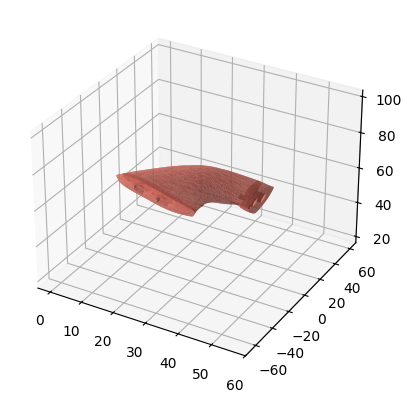

In [4]:

if __name__ == "__main__":
    # --- File and Resolution Settings ---
    filename = "Prototipo_Muscolo Stern_DX.stl"
    PITCH = 4.0      # Voxel size (spatial resolution)
    DT = 0.005       # Time step (Critical for Courant stability in Continuum solvers)
    
    # --- Material Properties (Biologically Realistic for Muscle) ---
    # Stiffness (Young's Modulus): Controls resistance to deformation.
    # 1500.0 is tuned for a "relaxed" muscle appearance in this normalized scale.
    YOUNGS_MODULUS = 1500.0 
    
    # Poisson's Ratio: Controls compressibility.
    # 0.4 implies nearly incompressible (volume preserving), typical for biological tissue.
    POISSON_RATIO = 0.4     
    DENSITY = 1.0
    
    # Simulation Duration
    STEPS = 200
    FORCE_DUR = 40
    
    method='euler' #or euler
    # 1. Setup Voxel Graph and Skinning
    # Note: 'edges' is now returned to define connectivity for gradient computation
    visual_mesh, phys_nodes, L, skin_idx, skin_w, edges = setup_voxel_graph(filename, PITCH)
    
    # 2. Define Boundary Conditions and External Forces
    # Detect Longitudinal Axis
    extent = phys_nodes.max(axis=0) - phys_nodes.min(axis=0)
    long_axis = np.argmax(extent)
    coords = phys_nodes[:, long_axis]
    length = coords.max() - coords.min()
    
    # Tendon Attachment (Fixed Ends)
    fixed_mask = (coords < (coords.min() + length*0.1)) | (coords > (coords.max() - length*0.1))
    
    # Impact Region (Muscle Belly)
    muscle_center = np.mean(phys_nodes, axis=0)
    dist_from_center = np.linalg.norm(phys_nodes - muscle_center, axis=1)
    force_mask = dist_from_center < (length * 0.15)
    
    # Define Force Vector (Perpendicular impact)
    force_vec = np.zeros(3)
    punch_axis = (long_axis + 1) % 3
    force_vec[punch_axis] = 80.0 
    
    # 3. Initialize Continuum Solver
    # We pass the graph topology (edges) and physical parameters to the solver.
    solver = ContinuumGNN(phys_nodes, edges, fixed_mask, YOUNGS_MODULUS, POISSON_RATIO, DENSITY, DT)
    
    # Initialize State Variables (Displacement, Velocity, Force)
    u = np.zeros_like(phys_nodes)
    v = np.zeros_like(phys_nodes)
    f_ext = np.zeros_like(phys_nodes)
    f_ext[force_mask] = force_vec
    
    visual_history = []
    
    print("Running Continuum Simulation (Cauchy Elastic)...")
    for step in range(STEPS):
        # Impulse Logic: Turn off force after FORCE_DUR steps
        if step == FORCE_DUR:
            f_ext[:] = 0.0
            
        # Physics Step: Integrate Cauchy Momentum Equation
        if method=='rk4':
            u, v = solver.update_rk4(u, v, f_ext)
        else:
            u, v=solver.update_euler(u,v,f_ext)
        
        # Visualization Step (Downsampling for performance)
        if step % 2 == 0:
            # Skinning: Interpolate physical node displacement to high-res mesh
            weighted_disp = (u[skin_idx] * skin_w[:, :, np.newaxis]).sum(axis=1)
            visual_history.append(visual_mesh.vertices + weighted_disp)
            print(f"Step {step}/{STEPS}")

    # 4. Generate Animation (Matplotlib)
    print("Creating animation...")
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    verts_0 = visual_mesh.vertices
    margin = 20
    ax.set_xlim(verts_0[:,0].min()-margin, verts_0[:,0].max()+margin)
    ax.set_ylim(verts_0[:,1].min()-margin, verts_0[:,1].max()+margin)
    ax.set_zlim(verts_0[:,2].min()-margin, verts_0[:,2].max()+margin)
    
    def animate(frame):
        ax.clear()
        ax.set_xlim(verts_0[:,0].min()-margin, verts_0[:,0].max()+margin)
        ax.set_ylim(verts_0[:,1].min()-margin, verts_0[:,1].max()+margin)
        ax.set_zlim(verts_0[:,2].min()-margin, verts_0[:,2].max()+margin)
        v_now = visual_history[frame]
        ax.plot_trisurf(v_now[:,0], v_now[:,1], v_now[:,2], triangles=visual_mesh.faces, color='salmon', alpha=0.8)
        return fig,

    anim = FuncAnimation(fig, animate, frames=len(visual_history), interval=40)
    if method!='rk4':
        anim.save('muscle_continuum_euler.gif', writer='pillow', fps=30)
    else:
        anim.save('muscle_continuum.gif', writer='pillow', fps=30)

    print("Done.")